In [1]:
from turtledemo.clock import display_date_time

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score, mutual_info_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import xgboost as xgb


In [2]:
df = pd.read_csv('data.csv', sep = ';', header=0)
cols = ['marital_status', 'app_mode', 'app_order', 'course', 'day_evening', 'prev_qual', 'prev_qual_grade', 'nationality', 'mother_qual',
        'father_qual', 'mother_occupation', 'father_occupation', 'admission_grade', 'displaced', 'special_needs', 'debtor', 'tuition_updated',
        'gender', 'scholarship', 'enrolled_age', 'international', 'sem1_units_credited', 'sem1_units_enrolled', 'sem1_unit_evals', 'sem1_unit_approved',
        'sem1_grades', 'sem1_units_noeval', 'sem2_units_credited', 'sem2_units_enrolled', 'sem2_unit_evals', 'sem2_unit_approved', 'sem2_grades',
        'sem2_units_noeval', 'unemployment', 'inflation', 'gdp', 'target']
df.columns = cols
df.head()

,marital_status,app_mode,app_order,course,day_evening,prev_qual,prev_qual_grade,nationality,mother_qual,father_qual,...,sem2_units_credited,sem2_units_enrolled,sem2_unit_evals,sem2_unit_approved,sem2_grades,sem2_units_noeval,unemployment,inflation,gdp,target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
# dataset currently has target encoded as a 3-way classification.  since we haven't addressed this yet via the class, adding a separate column
# to turn this into a binary classification problem (either dropped out or not).  Stretch goal will be to evaluate both binary and multi-state classifications...
target_trans = {'Graduate': 0, 'Dropout': 1, 'Enrolled': 0}
df['dropout'] = df['target'].apply(lambda x: target_trans[x])
target_trans = {'Graduate': 0, 'Dropout': 1, 'Enrolled': 2}
df['target'] = df['target'].apply(lambda x: target_trans[x])  # make all columns numeric

In [4]:
df_full_train, df_test = train_test_split(df, test_size = 0.2, random_state = 11)
df_full_train = df_full_train.reset_index(drop = True)
df_test = df_test.reset_index(drop=True)

y_full_train = df_full_train.dropout.values
y_test = df_test.dropout.values

df_full_train.drop(['dropout', 'target'], axis=1, inplace=True)
df_test.drop(['dropout', 'target'], axis=1, inplace=True)

In [5]:
dv = DictVectorizer(sparse=False)

train_dict = df_full_train.to_dict(orient = 'records')
test_dict = df_test.to_dict(orient = 'records')

X_train = dv.fit_transform(train_dict)
X_test = dv.transform(test_dict )

In [7]:
from sklearn.preprocessing import StandardScaler  #significantly reduces run time and produces roughly identical results
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scale_model = LogisticRegression(C=10)
scale_model.fit(X_train_scaled, y_full_train)
logr_y_pred_scale = scale_model.predict_proba(X_test_scaled)[:,1]
print('Scaled logistic regression model AUC = %.3f' % (roc_auc_score(y_test, logr_y_pred_scale)))

Scaled logistic regression model AUC = 0.911


In [14]:
dict(zip(dv.get_feature_names_out(), scale_model.coef_[0].round(3)))

{'admission_grade': np.float64(-0.079),
 'app_mode': np.float64(0.035),
 'app_order': np.float64(0.113),
 'course': np.float64(0.266),
 'day_evening': np.float64(0.03),
 'debtor': np.float64(0.166),
 'displaced': np.float64(0.198),
 'enrolled_age': np.float64(0.391),
 'father_occupation': np.float64(-0.033),
 'father_qual': np.float64(-0.049),
 'gdp': np.float64(0.026),
 'gender': np.float64(0.144),
 'inflation': np.float64(0.079),
 'international': np.float64(-0.237),
 'marital_status': np.float64(-0.055),
 'mother_occupation': np.float64(-0.238),
 'mother_qual': np.float64(0.164),
 'nationality': np.float64(0.183),
 'prev_qual': np.float64(-0.14),
 'prev_qual_grade': np.float64(0.023),
 'scholarship': np.float64(-0.236),
 'sem1_grades': np.float64(0.21),
 'sem1_unit_approved': np.float64(-0.942),
 'sem1_unit_evals': np.float64(-0.118),
 'sem1_units_credited': np.float64(0.47),
 'sem1_units_enrolled': np.float64(-0.053),
 'sem1_units_noeval': np.float64(-0.093),
 'sem2_grades': np.flo

In [18]:
from sklearn.metrics import mutual_info_score
def mi_drop_score (series):
    return mutual_info_score(y_full_train, series)
df_full_train.apply(mi_drop_score).sort_values(ascending = False)

C:\Users\akjnm\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received binary values for label, and continuous values for target
  warnings.warn(msg, UserWarning)
C:\Users\akjnm\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received binary values for label, and continuous values for target
  warnings.warn(msg, UserWarning)
C:\Users\akjnm\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received binary values for label, and continuous values for target
  warnings.warn(msg, UserWarning)
C:\Users\akjnm\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received binary values for label, and

sem2_grades            0.244908
sem2_unit_approved     0.221007
sem1_grades            0.212298
sem1_unit_approved     0.174539
admission_grade        0.123092
tuition_updated        0.088832
sem2_unit_evals        0.072152
sem1_unit_evals        0.057786
enrolled_age           0.052490
prev_qual_grade        0.050399
app_mode               0.046011
course                 0.035877
scholarship            0.035319
sem1_units_enrolled    0.035083
sem2_units_enrolled    0.028372
debtor                 0.025891
mother_occupation      0.024672
prev_qual              0.022960
father_qual            0.022843
mother_qual            0.021615
gender                 0.020232
father_occupation      0.019683
marital_status         0.005935
displaced              0.005596
app_order              0.004704
sem1_units_noeval      0.004620
sem2_units_noeval      0.004338
sem1_units_credited    0.004243
sem2_units_credited    0.003771
gdp                    0.003391
unemployment           0.003391
day_even

## Cross-validation (KFold)

In [8]:
def train(df_train, y_train, C=1.0):
    dicts = df_train.to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(C=C, max_iter=10000)
    model.fit(X_train, y_train)

    return dv, X_train, model

In [9]:
def predict(df, dv, model):
    dicts = df.to_dict(orient = 'records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:,1]

    return y_pred

## Decision Tree

In [10]:
dt = DecisionTreeClassifier(max_depth = 4, min_samples_leaf = 95)
dt.fit(X_train, y_full_train)
dt_y_pred = dt.predict_proba(X_test)[:,1]
print('Decision Tree score = %.3f' % (roc_auc_score(y_test, dt_y_pred)))

Decision Tree score = 0.872


## Random Forest

In [11]:
#final RandomForest model
rf = RandomForestClassifier(n_estimators = 125, max_depth = 15, min_samples_leaf = 5, random_state = 1)
rf.fit(X_train, y_full_train)
rf_y_pred = rf.predict_proba(X_test)[:,1]
print('RandomForest score = %.3f' % (roc_auc_score(y_test, rf_y_pred)))

RandomForest score = 0.905


C:\Users\akjnm\AppData\Local\Temp\ipykernel_17504\3621754533.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='feature_importances', y='feature_names', data=importance_df, palette='Blues_r')


Text(0.5, 1.0, 'Feature Importance Chart')

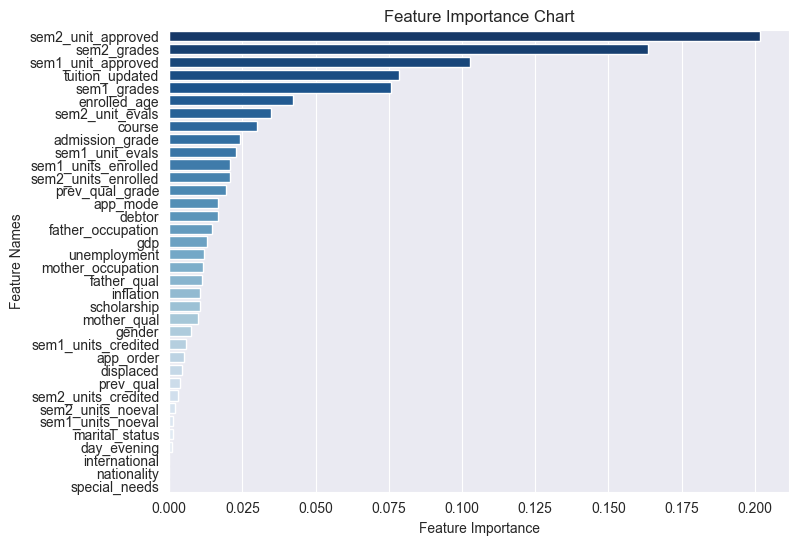

In [13]:
importance_df = pd.DataFrame(list(zip(dv.get_feature_names_out(), rf.feature_importances_)), columns=['feature_names', 'feature_importances'])
importance_df = importance_df.sort_values(by='feature_importances', ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x='feature_importances', y='feature_names', data=importance_df, palette='Blues_r')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Names')
plt.title('Feature Importance Chart')

## XGBoost

In [12]:
xgb_params = {
        'eta': 0.05,
        'max_depth': 6,
        'min_child_weight': 1,
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'nthread': 4,
        'seed': 1,
        'verbosity': 1,
    }

features = list(dv.get_feature_names_out())
d_fulltrain = xgb.DMatrix(X_train, label = y_full_train, feature_names = features)
d_test = xgb.DMatrix(X_test, feature_names = list(dv.get_feature_names_out()))

xgb_model = xgb.train(xgb_params,d_fulltrain, num_boost_round = 150)
xgb_y_pred = xgb_model.predict(d_test)
print('XGBoost AUC score = %.3f' % roc_auc_score(y_test, xgb_y_pred))

XGBoost AUC score = 0.916


## Summary

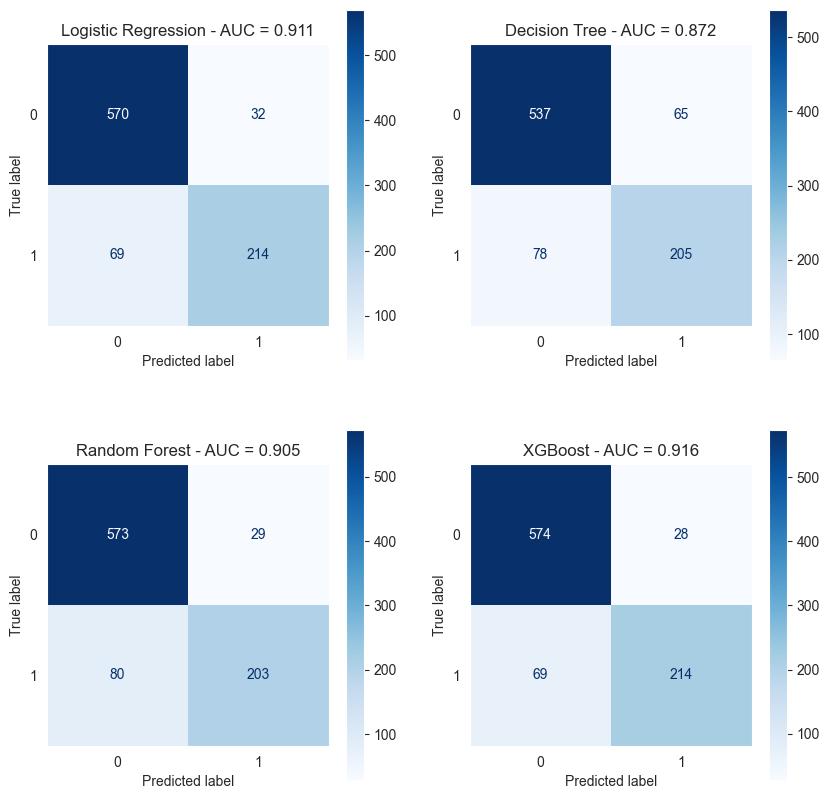

In [72]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize = (10,10))

disp_log = ConfusionMatrixDisplay.from_predictions(y_test, (logr_y_pred_scale >= 0.5).astype(int), cmap = 'Blues', ax = axes[0][0]).ax_.grid(False)
disp_dt = ConfusionMatrixDisplay.from_predictions(y_test, (dt_y_pred >= 0.5).astype(int), cmap = 'Blues', ax= axes[0][1]).ax_.grid(False)
disp_rf = ConfusionMatrixDisplay.from_predictions(y_test, (rf_y_pred >= 0.5).astype(int), cmap = 'Blues', ax= axes[1][0]).ax_.grid(False)
disp_xgb = ConfusionMatrixDisplay.from_predictions(y_test, (xgb_y_pred >= 0.5).astype(int), cmap = 'Blues', ax = axes[1][1]).ax_.grid(False)

axes[0][0].set_title('Logistic Regression - AUC = %.3f' % (roc_auc_score(y_test, logr_y_pred_scale)))
axes[0][1].set_title('Decision Tree - AUC = %.3f' % (roc_auc_score(y_test, dt_y_pred)))
axes[1][0].set_title('Random Forest - AUC = %.3f' % (roc_auc_score(y_test, rf_y_pred)))
axes[1][1].set_title('XGBoost - AUC = %.3f' % (roc_auc_score(y_test, xgb_y_pred)))

plt.show()

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

array([[<Axes: >, <Axes: >],
       [<Axes: >, <Axes: >]], dtype=object)

In [95]:
df_full_train.iloc[13].to_dict()

{'marital_status': 1.0,
 'app_mode': 39.0,
 'app_order': 1.0,
 'course': 9991.0,
 'day_evening': 0.0,
 'prev_qual': 19.0,
 'prev_qual_grade': 133.1,
 'nationality': 1.0,
 'mother_qual': 2.0,
 'father_qual': 1.0,
 'mother_occupation': 2.0,
 'father_occupation': 4.0,
 'admission_grade': 100.0,
 'displaced': 0.0,
 'special_needs': 0.0,
 'debtor': 0.0,
 'tuition_updated': 1.0,
 'gender': 1.0,
 'scholarship': 0.0,
 'enrolled_age': 24.0,
 'international': 0.0,
 'sem1_units_credited': 0.0,
 'sem1_units_enrolled': 5.0,
 'sem1_unit_evals': 7.0,
 'sem1_unit_approved': 0.0,
 'sem1_grades': 0.0,
 'sem1_units_noeval': 0.0,
 'sem2_units_credited': 0.0,
 'sem2_units_enrolled': 5.0,
 'sem2_unit_evals': 7.0,
 'sem2_unit_approved': 0.0,
 'sem2_grades': 0.0,
 'sem2_units_noeval': 0.0,
 'unemployment': 16.2,
 'inflation': 0.3,
 'gdp': -0.92}

In [76]:
def train(df_train, y_train):
    dicts = df_train.to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    dtrain = xgb.DMatrix(X_train, label=y_train, feature_names = list(dv.get_feature_names_out()))
    model = xgb.train(xgb_params, dtrain, num_boost_round = 150)

    return dv, model

def predict(df_target, dv, model):
    dict = df_target.to_dict(orient = 'records')
    X_test = dv.transform(dict)

    d_test = xgb.DMatrix(X_test, feature_names = list(dv.get_feature_names_out()))
    return model.predict(d_test)

dv, model = train(df_full_train.drop(['dropout', 'target'], axis=1), y_full_train)
y_pred = predict(df_test.drop(['dropout', 'target'], axis=1), dv, model)
print('Model initial AUC score = %.3f' % roc_auc_score(y_test, y_pred))

# model validation
print(f'Validating model across {n_splits} KFold splits')
kfold = KFold(n_splits=n_splits, shuffle=True, random_state=11)

scores = []
fold = 0

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train.dropout.values
    y_val = df_val.dropout.values

    dv, model = train(df_train.drop(['dropout', 'target'], axis=1), y_train)
    y_pred = predict(df_val.drop(['dropout', 'target']), dv, model)

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)
    print(f'AUC on fold {fold} is {auc}')
    fold += 1

KeyError: "['dropout', 'target'] not found in axis"